In [2]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
tf.random.set_seed(42)

Download the data sets and normalise the data
For MNIST: 
    - Use min-max scaling, so that the values are in range[0,1]
For CIFAR-10:
    -Use Z score normalisation (mean=0, stdev=1)

In [2]:
from tensorflow.keras.datasets import mnist, cifar10
import numpy as np

(x_raw, y_raw), (x_test_raw, y_test)= mnist.load_data()

val_size = int(x_raw.shape[0] * 0.3)
rng = np.random.default_rng(42)  # seed for reproducibility
idx = np.arange(x_raw.shape[0])
rng.shuffle(idx)

val_idx = idx[:val_size]
train_idx = idx[val_size:]

(x_train_raw, y_train), (x_val_raw, y_val) = (x_raw[train_idx], y_raw[train_idx]), (x_raw[val_idx], y_raw[val_idx])


(x_raw_cif, y_cif), (x_test_cif_raw, y_test_cif) = cifar10.load_data()

val_size_cif = int(x_raw_cif.shape[0]*0.3)
idx_cif = np.arange(x_raw_cif.shape[0])
rng.shuffle(idx_cif)

val_idx_cif = idx_cif[:val_size_cif]
train_idx_cif = idx_cif[val_size_cif:]

(x_train_cif_raw, y_train_cif), (x_val_cif_raw, y_val_cif) = (x_raw_cif[train_idx_cif], y_cif[train_idx_cif]), (x_raw_cif[val_idx_cif], y_cif[val_idx_cif])

x_train_cif_type = x_train_cif_raw.astype("float32")
x_test_cif_type = x_test_cif_raw.astype("float32")
x_validation_cif_type = x_val_cif_raw.astype("float32")

In [16]:
import matplotlib.pyplot as plt
import numpy as np
    
x_train, x_test, x_val= x_train_raw/255.0, x_test_raw/255.0, x_val_raw/255.0

def z_score_normalisation(train, test, validation):
    mean = np.mean(train, axis= (0,1,2), keepdims=True)
    std = np.std(train, axis= (0,1,2), keepdims=True)

    return (train - mean) / std, (test - mean) / std, (validation -mean) /std


x_train_cif, x_test_cif, x_val_cif = z_score_normalisation(x_train_cif_type, x_test_cif_type, x_validation_cif_type)



MNIST. 
Train (with Adam optimizer) a CNN with:
    -First layer: Convolution layer wtih 16-64 filters (3x3), ReLu activation and batch normalisation
    -Second layer: Max pooling (2x2)
    -Third layer: Convolution layer with 32-128 filters (3x3), ReLu activation and batch normalisation
    -Fourth layer: max pooling (2x2)
    -Fifth layer: (after flattening the output from fourth later): A fully connected ("dense") layer with 128 neurons, ReLu activation (and dropout during training with suitable dropout range (somewhere in [0.2, 0.5]))
    -Sixth layer: a layer with 10 neurons (the number of classes) and a softmax activation function

In [45]:
print(x_train.dtype, x_train.shape)
print("min/max:", x_train.min(), x_train.max())


float64 (60000, 28, 28)
min/max: 0.0 1.0


In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Input(shape = (28,28,1)),
    #1
    layers.Conv2D(filters=16, kernel_size = (3,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    #2
    layers.MaxPooling2D((2,2)),

    #3
    layers.Conv2D(filters=32, kernel_size=(3,3)),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    #4
    layers.MaxPooling2D((2,2)),

    #5
    layers.Flatten(),
    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.4),

    #6
    layers.Dense(10, activation = "softmax")
])

model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) #Is the loss and metrics correct?
fitted = model.fit(x_train, y_train, epochs = 10, batch_size = 64, validation_data = (x_val, y_val))

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy: ", test_acc)


Epoch 1/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9165 - loss: 0.2727 - val_accuracy: 0.9727 - val_loss: 0.0875
Epoch 2/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.9718 - loss: 0.0924 - val_accuracy: 0.9794 - val_loss: 0.0707
Epoch 3/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.9782 - loss: 0.0709 - val_accuracy: 0.9863 - val_loss: 0.0467
Epoch 4/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.9830 - loss: 0.0570 - val_accuracy: 0.9837 - val_loss: 0.0549
Epoch 5/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.9840 - loss: 0.0500 - val_accuracy: 0.9715 - val_loss: 0.1067
Epoch 6/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.9855 - loss: 0.0442 - val_accuracy: 0.9890 - val_loss: 0.0430
Epoch 7/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.9880 - loss: 0.0385 - val_accuracy: 0.9829 - val_loss: 0.0623
Epoch 8/10
657/657 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.9878 - loss: 0.0365 - 

In [49]:
print(x_train_cif.shape)
print(y_train_cif.shape)
print(y_train_cif[:5])

(50000, 32, 32, 3)
(50000, 1)
[[6]
 [9]
 [9]
 [4]
 [1]]


In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models
model_cif = models.Sequential([
    layers.Input(shape = (32,32,3)),
    #1
    layers.Conv2D(filters=16, kernel_size = (3,3), padding = "same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    #2
    layers.MaxPooling2D((2,2)),

    #3
    layers.Conv2D(filters=32, kernel_size=(3,3), padding = "same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    #4
    layers.MaxPooling2D((2,2)),

    #5
    layers.Conv2D(filters=32, kernel_size=(3,3), padding = "same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    #6
    layers.MaxPooling2D((2,2)),

    #5
    layers.Flatten(),
    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.4),

    #6
    layers.Dense(10, activation = "softmax")
])

model_cif.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) #Is the loss and metrics correct?
fitted_cif = model_cif.fit(x_train_cif, y_train_cif, epochs = 10, batch_size = 64, validation_data = (x_val_cif, y_val_cif))

test_loss_cif, test_acc_cif = model_cif.evaluate(x_test_cif, y_test_cif)
print("Test accuracy: ", test_acc_cif)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 35ms/step - accuracy: 0.3973 - loss: 1.6601 - val_accuracy: 0.5011 - val_loss: 1.3871
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.5283 - loss: 1.3078 - val_accuracy: 0.5718 - val_loss: 1.1999
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.5855 - loss: 1.1584 - val_accuracy: 0.6227 - val_loss: 1.0874
Epoch 4/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 23s 41ms/step - accuracy: 0.6234 - loss: 1.0623 - val_accuracy: 0.6267 - val_loss: 1.0409
Epoch 5/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - accuracy: 0.6433 - loss: 1.0004 - val_accuracy: 0.6528 - val_loss: 0.9948
Epoch 6/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.6605 - loss: 0.9494 - val_accuracy: 0.6613 - val_loss: 0.9559
Epoch 7/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 36ms/step - accuracy: 0.6760 - loss: 0.9135 - val_accuracy: 0.6811 - val_loss: 0.9057
Epoch 8/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.6909 - loss: 0.8752 - 

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
model_cif = models.Sequential([
    layers.Input(shape = (32,32,3)),
    #1
    layers.Conv2D(filters=32, kernel_size = (3,3), padding = "same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    #2
    layers.MaxPooling2D((2,2)),

    #3
    layers.Conv2D(filters=64, kernel_size=(3,3), padding = "same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    #4
    layers.MaxPooling2D((2,2)),

    #5
    layers.Conv2D(filters=64, kernel_size=(3,3), padding = "same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    #6
    layers.MaxPooling2D((2,2)),

    #5
    layers.Flatten(),
    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.4),

    #6
    layers.Dense(10, activation = "softmax")
])

model_cif.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) #Is the loss and metrics correct?
fitted_cif = model_cif.fit(x_train_cif, y_train_cif, epochs = 10, batch_size = 64, validation_data = (x_test_cif, y_test))

test_loss_cif, test_acc_cif = model_cif.evaluate(x_test_cif, y_test_cif)
print("Test accuracy: ", test_acc_cif)

Epoch 1/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 38s 59ms/step - accuracy: 0.3999 - loss: 1.6339 - val_accuracy: 0.0990 - val_loss: 3.9991
Epoch 2/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 33s 60ms/step - accuracy: 0.5381 - loss: 1.2665 - val_accuracy: 0.0997 - val_loss: 4.5226
Epoch 3/10
547/547 ━━━━━━━━━━━━━━━━━━━━ 28s 51ms/step - accuracy: 0.5997 - loss: 1.1199 - val_accuracy: 0.0948 - val_loss: 5.2462
Epoch 4/10
232/547 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.6302 - loss: 1.0482

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
model_cif2 = models.Sequential([

    layers.Input(shape = (32,32,3)),
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),
    
    #1
    layers.Conv2D(filters=32, kernel_size = (3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    #2
    layers.Conv2D(filters=32, kernel_size = (3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    #3
    layers.MaxPooling2D((2,2)),

    #4
    layers.Conv2D(filters=64, kernel_size=(3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    #5
    layers.Conv2D(filters=64, kernel_size=(3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    #6
    layers.MaxPooling2D((2,2)),

    #7
    layers.Conv2D(filters=128, kernel_size=(3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    #8
    layers.Conv2D(filters=128, kernel_size=(3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    #9
    layers.MaxPooling2D((2,2)),

    #10
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.4),

    #11
    layers.Dense(10, activation = "softmax")
])

model_cif2.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) #Is the loss and metrics correct?
fitted_cif2 = model_cif2.fit(x_train_cif, y_train_cif, epochs = 10, batch_size = 64, validation_data = (x_test_cif, y_test))

test_loss_cif2, test_acc_cif2 = model_cif2.evaluate(x_test_cif, y_test_cif)
print("Test accuracy: ", test_acc_cif2)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 101s 122ms/step - accuracy: 0.3898 - loss: 1.6482 - val_accuracy: 0.4043 - val_loss: 1.6681
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 116s 149ms/step - accuracy: 0.5324 - loss: 1.2998 - val_accuracy: 0.4211 - val_loss: 1.6070
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 93s 119ms/step - accuracy: 0.5937 - loss: 1.1529 - val_accuracy: 0.5401 - val_loss: 1.2894
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 100s 128ms/step - accuracy: 0.6271 - loss: 1.0607 - val_accuracy: 0.5724 - val_loss: 1.2228
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 136ms/step - accuracy: 0.6540 - loss: 0.9824 - val_accuracy: 0.5749 - val_loss: 1.1865
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 135ms/step - accuracy: 0.6772 - loss: 0.9302 - val_accuracy: 0.6511 - val_loss: 1.0154
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 113ms/step - accuracy: 0.6937 - loss: 0.8832 - val_accuracy: 0.6370 - val_loss: 1.0812
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 125ms/step - accuracy: 0.7145 - lo

In the one before this we added: 
    -More filters (num feature maps it represents), if they are too few it cant represent all the distinct features needed to differentiate the different objects
    -More convolution layers before pooling helps get a better representation of what features the image has before we compress it
    -GlobalAveragePooling2D instead of flatten: I averages the feature map for each colour instead of creating a big vector with the values for all heights, widths and colours. This means fewer parameters and less sensitivity tot he exact location of a feature
    -Added dropout in more locations: Randomly removes some data. Avoids overfitting by forcing it to not rely too much on any single activation
    -Data augmentation bcs it creates "extra data" by teaching the model to handle objects that are shifted slightly or mirrored

In [ ]:
import tensorflow as tf
tf.random.set_seed(42)

In [ ]:

from tensorflow.keras import callbacks
model_cif = models.Sequential([

    layers.Input(shape = (32,32,3)),
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),
    
    #1
    layers.Conv2D(filters=32, kernel_size = (3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    #2
    layers.Conv2D(filters=32, kernel_size = (3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    #3
    layers.MaxPooling2D((2,2)),

    #4
    layers.Conv2D(filters=64, kernel_size=(3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    #5
    layers.Conv2D(filters=64, kernel_size=(3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.25),

    #6
    layers.MaxPooling2D((2,2)),

    #7
    layers.Conv2D(filters=128, kernel_size=(3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    #8
    layers.Conv2D(filters=128, kernel_size=(3,3), padding = "same", use_bias = False),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    #9
    layers.MaxPooling2D((2,2)),

    #10
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation = "relu"),
    layers.Dropout(0.4),

    #11
    layers.Dense(10, activation = "softmax")
])

model_cif.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"]) #Is the loss and metrics correct?
early_stopping = callbacks.EarlyStopping(monitor = "val_loss", patience = 4, restore_best_weights = True)
fitted_cif = model_cif.fit(x_train_cif, y_train_cif, epochs = 10, batch_size = 64, validation_data = (x_test_cif, y_test_cif), callbacks = [early_stopping])

test_loss_cif, test_acc_cif = model_cif.evaluate(x_test_cif, y_test_cif)
print("Test accuracy: ", test_acc_cif)

Implement kNN models for both.
Use the standard euclidean distance measure (applied pixel-by picel)
Run each model with different values of k (from 1-25 eg.). Pick the k with the highers validation accuracy.
Use that to obtain testing accuracy

In [55]:
pip install scikit-learn scikit-image

Note: you may need to restart the kernel to use updated packages.


Flatten each image
Scale data (min-max scaling to put all values in [0, 1])
Distance computation: sum distances (squared, if euclidean norm) over all elements, computed pixel by pixel (compare test image pixels with those of image Ii in data set)
sort (together with label) the distances in increasing order
voting: take the majority label among the k-nearest neighbours

In [19]:

def flatten(x):
    return x.reshape(x.shape[0], -1)

flattened_x_train, flattened_x_test, flattened_x_val = flatten(x_train), flatten(x_test), flatten(x_val)

flattened_x_train_CIFAR, flattened_x_test_CIFAR, flattened_x_val_CIFAR = flatten(x_train_cif), flatten(x_test_cif), flatten(x_val_cif)


In [6]:
#Distance computation
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score



In [21]:
for k in range(1,26):
    knn = KNeighborsClassifier(
        n_neighbors = k, 
        metric = "euclidean",
        weights = "distance"
    )

    knn.fit(flattened_x_train, y_train)
    prediction = knn.predict(flattened_x_val)

    print("Accuracy: ", accuracy_score(y_val, prediction), " for k = ", k)

Accuracy:  0.9712777777777778  for k =  1
Accuracy:  0.9712777777777778  for k =  2
Accuracy:  0.9715555555555555  for k =  3
Accuracy:  0.9741111111111111  for k =  4
Accuracy:  0.9714444444444444  for k =  5
Accuracy:  0.9728333333333333  for k =  6
Accuracy:  0.9701666666666666  for k =  7
Accuracy:  0.9708333333333333  for k =  8
Accuracy:  0.9681666666666666  for k =  9
Accuracy:  0.9686111111111111  for k =  10
Accuracy:  0.9664444444444444  for k =  11
Accuracy:  0.967  for k =  12
Accuracy:  0.9651111111111111  for k =  13
Accuracy:  0.9658888888888889  for k =  14
Accuracy:  0.9641666666666666  for k =  15
Accuracy:  0.9647222222222223  for k =  16
Accuracy:  0.9632777777777778  for k =  17
Accuracy:  0.963  for k =  18
Accuracy:  0.9615555555555556  for k =  19
Accuracy:  0.9619444444444445  for k =  20
Accuracy:  0.9607222222222223  for k =  21
Accuracy:  0.9614444444444444  for k =  22
Accuracy:  0.9598888888888889  for k =  23
Accuracy:  0.9597777777777777  for k =  24
Acc

In [24]:
for k in range(1,26):
    knn = KNeighborsClassifier(
        n_neighbors = k, 
        metric = "euclidean",
        weights = "distance"
    )



    knn.fit(flattened_x_train_CIFAR, y_train_cif)
    prediction = knn.predict(flattened_x_val_CIFAR)

    print("Accuracy: ", accuracy_score(y_val_cif, prediction), " for k = ", k)

c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3369333333333333  for k =  1


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3369333333333333  for k =  2


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3403333333333333  for k =  3


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.34186666666666665  for k =  4


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3383333333333333  for k =  5


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.33853333333333335  for k =  6


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3379333333333333  for k =  7


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3392  for k =  8


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.33566666666666667  for k =  9


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.33413333333333334  for k =  10


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3347333333333333  for k =  11


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3342  for k =  12


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3320666666666667  for k =  13


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.33086666666666664  for k =  14


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.32926666666666665  for k =  15


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3297333333333333  for k =  16


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3294  for k =  17


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3277333333333333  for k =  18


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.32466666666666666  for k =  19


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.32653333333333334  for k =  20


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.325  for k =  21


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3234  for k =  22


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3228  for k =  23


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.3224666666666667  for k =  24


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Accuracy:  0.32126666666666664  for k =  25


In [25]:
test_examples = [0, 5, 50, 500, 5000]

k = 4

knn = KNeighborsClassifier(
        n_neighbors = k, 
        metric = "euclidean",
        weights = "distance"
    )

knn.fit(flattened_x_train_CIFAR, y_train_cif)


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Predicted label:  4 True label:  3


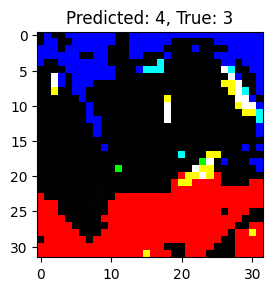

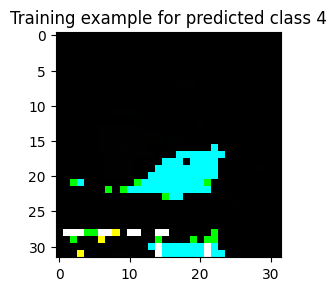

Predicted label:  6 True label:  6


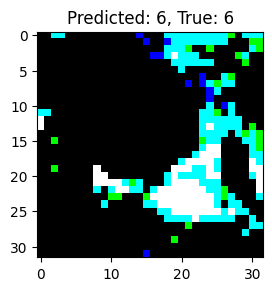

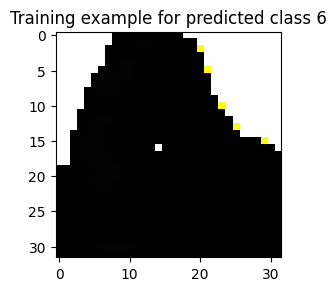

Predicted label:  7 True label:  9


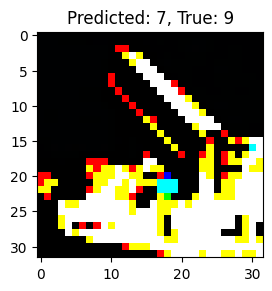

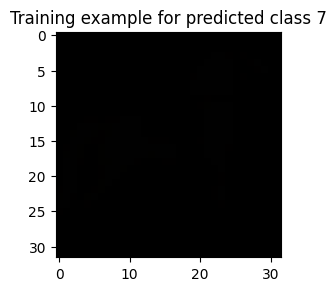

Predicted label:  4 True label:  4


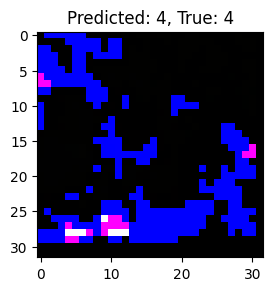

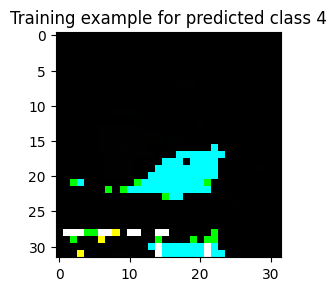

Predicted label:  4 True label:  7


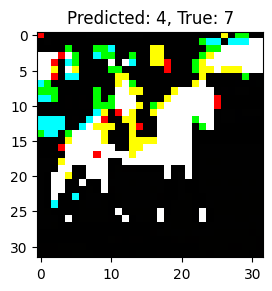

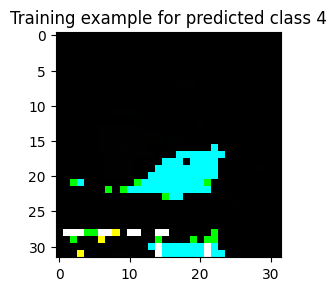

In [ ]:

for idx in test_examples:
    idx_spec = flattened_x_test_CIFAR[idx]
    idx_spec = idx_spec.reshape(1, -1)
    predict = knn.predict(idx_spec)[0]
    print("Predicted label: ", predict, "True label: ", y_test_cif[idx][0])

    plt.figure()
    plt.subplot(1,2,1)
    plt.imshow(x_test_cif_type[idx].astype("uint8"))
    plt.title(f"Predicted: {predict}, True: {y_test_cif[idx][0]}")
    plt.show()

    plt.subplot(1,2,2)
    plt.imshow(x_train_cif_type[np.where(y_train_cif == predict)[0][0]].astype("uint8"))
    plt.title(f"Training example for predicted class {predict}")
    plt.show()

Steps: 
    - Image-> HOG patches: Tile image, one HOG vector for each
    - HOG patches -> K-means clustered codebook. 
    - COunt occuranses of visual words -> Form histogram
    - COmpare histogram to image training set, sort and find k nearest neighbours as usual